Statistcs of True_error compared to absolute error and signed error

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import scikit_posthocs as sp

In [47]:
df = pd.read_csv("Output_extraction/ai_grading_final_v3.csv")

df["prompt_type"] = pd.Categorical(df["prompt_type"], 
    categories=["very_pessimistic", "pessimistic", "neutral", "confident", "very_confident"], 
    ordered=True)

required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
df = df.dropna()

df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])

df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

pd.set_option("display.max_rows", None)

We start with a simple comparison in a table

In [48]:
display(
    df.groupby("true_mistakes")[
        ["ai_error", "Absolute_error"]
    ].agg(["count", "mean", "std"])
)

ai_error                     Absolute_error                    
                 count      mean       std          count      mean       std
true_mistakes                                                                
0                  500  0.108000  0.369607            500  0.108000  0.369607
1                  500  0.338000  1.168969            500  0.362000  1.161747
2                  500  0.300000  0.967405            500  0.340000  0.954055
3                  500  0.208000  0.762824            500  0.276000  0.740893
4                  499  0.148297  0.675186            499  0.216433  0.656486
5                  500  0.150000  0.693153            500  0.250000  0.663612
6                  500  0.088000  0.699453            500  0.256000  0.656755
7                  500  0.044000  0.516331            500  0.188000  0.482827
8                  499 -0.028056  0.661031            499  0.280561  0.599065
9                  500 -0.092000  0.693179            500  0.288000  0.637077
10                 499 -0.116232  0.698907            499  0.292585  0.645159
11                 500 -0.154000  0.641176            500  0.270000  0.601518
12                 500 -0.302000  0.834379            500  0.390000  0.796976
13                 499 -0.382766  0.926941            499  0.434870  0.903622
14                 498 -0.429719  0.980740            498  0.453815  0.969803
15                 500 -0.466000  1.219762            500  0.466000  1.219762

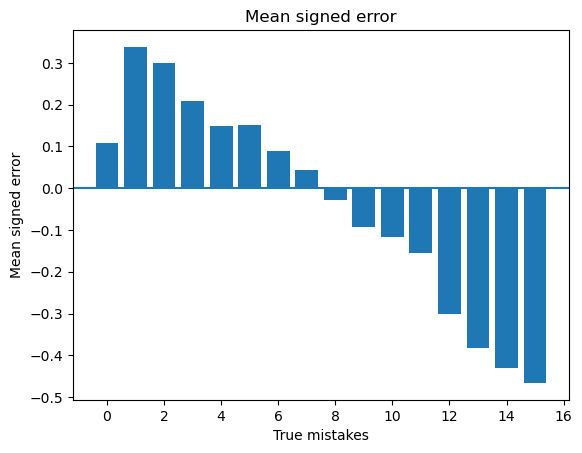

In [49]:
summary = df.groupby("true_mistakes")["ai_error"].agg(["mean", "std", "count"])


plt.bar(
    summary.index,
    summary["mean"],
    capsize=5
)

plt.axhline(0)
plt.xlabel("True mistakes")
plt.ylabel("Mean signed error")
plt.title("Mean signed error")
plt.show()

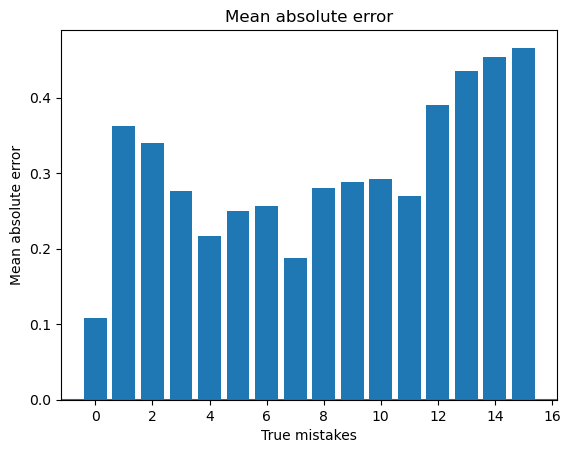

In [55]:
summary = df.groupby("true_mistakes")["Absolute_error"].agg(["mean", "std", "count"])


plt.bar(
    summary.index,
    summary["mean"],
    capsize=5
)

plt.axhline(0)
plt.xlabel("True mistakes")
plt.ylabel("Mean absolute error")
plt.title("Mean absolute error")
plt.show()

In [51]:
# ── Kruskal-Wallis for true_mistakes ───────────────────────────────────────────

# Med ai_error (signed)
kw_signed = pg.kruskal(
    data=df,
    dv="ai_error",
    between="true_mistakes"
)
print("=== Kruskal-Wallis: ai_error (signed) ===")
print(kw_signed)

# Med Absolute_error
kw_absolute = pg.kruskal(
    data=df,
    dv="Absolute_error",
    between="true_mistakes"
)
print("\n=== Kruskal-Wallis: Absolute_error ===")
print(kw_absolute)

=== Kruskal-Wallis: ai_error (signed) ===
                Source  ddof1           H          p_unc
Kruskal  true_mistakes     15  679.035205  5.447794e-135

=== Kruskal-Wallis: Absolute_error ===
                Source  ddof1          H         p_unc
Kruskal  true_mistakes     15  99.683983  1.497597e-14


Now using dunns becouse we see the p value is significant

In [52]:
def dunn_test(data, outcome):
    # Fjern eventuelle manglende værdier
    clean = data[["true_mistakes", outcome]].dropna()

    # Dunn-test med Holm-korrektion
    p_values = sp.posthoc_dunn(
        clean,
        val_col=outcome,
        group_col="true_mistakes",
        p_adjust="holm"
    )

    # Behold kun hver sammenligning én gang
    mask = np.triu(np.ones(p_values.shape, dtype=bool), k=1)

    results = (
        p_values
        .where(mask)
        .rename_axis(index="A", columns="B")
        .stack()
        .reset_index(name="p_corr")
        .dropna(subset=["p_corr"])
        .reset_index(drop=True)
    )

    return results

signed error

In [53]:
posthoc_signed_true = dunn_test(df, "ai_error")

display(posthoc_signed_true)
display(posthoc_signed_true[posthoc_signed_true["p_corr"] < 0.05])

,A,B,p_corr
0,0,1,1.000000e+00
1,0,2,1.000000e+00
2,0,3,1.000000e+00
3,0,4,1.000000e+00
4,0,5,1.000000e+00
5,0,6,1.000000e+00
6,0,7,5.668736e-01
7,0,8,9.129768e-05
8,0,9,6.672229e-06
9,0,10,8.265118e-07


,A,B,p_corr
7,0,8,9.129768e-05
8,0,9,6.672229e-06
9,0,10,8.265118e-07
10,0,11,2.092081e-11
11,0,12,2.057350e-20
12,0,13,3.119748e-25
13,0,14,1.700591e-29
14,0,15,1.058735e-27
20,1,7,1.385747e-02
21,1,8,1.215393e-07


Absolute error

In [54]:
posthoc_absolute_true = dunn_test(df, "Absolute_error")

print("\n=== Dunn's post-hoc test: absolute error ===")
display(posthoc_absolute_true)
display(posthoc_absolute_true[posthoc_absolute_true["p_corr"] < 0.05])


=== Dunn's post-hoc test: absolute error ===


,A,B,p_corr
0,0,1,9.389283e-01
1,0,2,3.941331e-02
2,0,3,3.960968e-02
3,0,4,1.000000e+00
4,0,5,2.195765e-01
5,0,6,2.570441e-02
6,0,7,7.626842e-01
7,0,8,2.699246e-05
8,0,9,1.775902e-04
9,0,10,1.121232e-04


,A,B,p_corr
1,0,2,3.941331e-02
2,0,3,3.960968e-02
5,0,6,2.570441e-02
7,0,8,2.699246e-05
8,0,9,1.775902e-04
9,0,10,1.121232e-04
10,0,11,2.166536e-04
11,0,12,2.355196e-08
12,0,13,1.897950e-09
13,0,14,3.310386e-09
